In [3]:
import pandas as pd

columns = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root",
    "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds",
    "is_host_login", "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "label", "difficulty"
]

train = pd.read_csv("data/KDDTrain+.txt", names=columns)
test = pd.read_csv("data/KDDTest+.txt", names=columns)

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (125973, 43)
Test shape: (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [4]:
# 1. What does each label look like?
print("Top labels in training data:")
print(train["label"].value_counts().head(10))

# 2. Make a simple column: normal or attack
train["is_attack"] = (train["label"] != "normal").astype(int)
test["is_attack"] = (test["label"] != "normal").astype(int)

# 3. How many normal vs attack?
print("\nTraining data: 0 = normal, 1 = attack")
print(train["is_attack"].value_counts())
print("\nPercent:")
print((train["is_attack"].value_counts(normalize=True) * 100).round(1))

print("\nTest data: 0 = normal, 1 = attack")
print(test["is_attack"].value_counts())

# 4. Missing values and text columns
print("\nMissing values in training data:", train.isnull().sum().sum())
print("Text columns:", list(train.select_dtypes(include="object").columns))

Top labels in training data:
label
normal         67343
neptune        41214
satan           3633
ipsweep         3599
portsweep       2931
smurf           2646
nmap            1493
back             956
teardrop         892
warezclient      890
Name: count, dtype: int64

Training data: 0 = normal, 1 = attack
is_attack
0    67343
1    58630
Name: count, dtype: int64

Percent:
is_attack
0    53.5
1    46.5
Name: proportion, dtype: float64

Test data: 0 = normal, 1 = attack
is_attack
1    12833
0     9711
Name: count, dtype: int64

Missing values in training data: 0
Text columns: ['protocol_type', 'service', 'flag', 'label']


C:\Users\Asus\AppData\Local\Temp\ipykernel_14588\3190609799.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print("Text columns:", list(train.select_dtypes(include="object").columns))


In [5]:
# 1. Split into clues (X) and answer (y)
# We drop "label" because it tells the model the answer directly (that would be cheating)
# We drop "difficulty" because it is not real traffic information
X_train = train.drop(columns=["label", "difficulty", "is_attack"])
y_train = train["is_attack"]

X_test = test.drop(columns=["label", "difficulty", "is_attack"])
y_test = test["is_attack"]

# 2. Turn text columns into numbers (0/1 columns)
text_columns = ["protocol_type", "service", "flag"]
X_train = pd.get_dummies(X_train, columns=text_columns, dtype=int)
X_test = pd.get_dummies(X_test, columns=text_columns, dtype=int)

# 3. Make test columns match train columns exactly
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# 4. Check the result
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Same columns in both:", list(X_train.columns) == list(X_test.columns))
print("Any text columns left:", len(X_train.select_dtypes(include="object").columns))
X_train.head()

X_train shape: (125973, 122)
X_test shape: (22544, 122)
Same columns in both: True
Any text columns left: 0


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,491,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0,146,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,0,232,8153,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
4,0,199,420,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# 1. Scale the numbers so big columns (like src_bytes) don't dominate small ones
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Train the model (it learns from the training data only)
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# 3. Predict on the test data (data the model has never seen)
y_pred = model.predict(X_test_scaled)

# 4. Results
print("Classification report (0 = normal, 1 = attack):")
print(classification_report(y_test, y_pred, target_names=["normal", "attack"]))

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print("Confusion matrix numbers:")
print("Normal correctly called normal (TN):", tn)
print("Normal wrongly called attack = false alarms (FP):", fp)
print("Attacks missed (FN):", fn)
print("Attacks caught (TP):", tp)
print("\nAttack recall (share of attacks caught):", round(tp / (tp + fn), 3))
print("False alarm rate (normal flagged as attack):", round(fp / (fp + tn), 3))

Classification report (0 = normal, 1 = attack):
              precision    recall  f1-score   support

      normal       0.65      0.93      0.76      9711
      attack       0.92      0.62      0.74     12833

    accuracy                           0.75     22544
   macro avg       0.78      0.77      0.75     22544
weighted avg       0.80      0.75      0.75     22544

Confusion matrix numbers:
Normal correctly called normal (TN): 8990
Normal wrongly called attack = false alarms (FP): 721
Attacks missed (FN): 4828
Attacks caught (TP): 8005

Attack recall (share of attacks caught): 0.624
False alarm rate (normal flagged as attack): 0.074


In [7]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# A helper that collects the important numbers for any model
def evaluate(name, y_true, y_hat):
    tn, fp, fn, tp = confusion_matrix(y_true, y_hat).ravel()
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_hat),
        "Attack recall": recall_score(y_true, y_hat),
        "Attack precision": precision_score(y_true, y_hat),
        "F1": f1_score(y_true, y_hat),
        "False alarm rate": fp / (fp + tn),
        "Attacks missed": fn,
    }

results = []

# 1. Baseline (from Step 8)
results.append(evaluate("Logistic Regression", y_test, y_pred))

# 2. Random Forest (does not need scaled data)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
results.append(evaluate("Random Forest", y_test, rf.predict(X_test)))

# 3. XGBoost
xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                    random_state=42, eval_metric="logloss")
xgb.fit(X_train, y_train)
results.append(evaluate("XGBoost", y_test, xgb.predict(X_test)))

# 4. Compare all three
comparison = pd.DataFrame(results).round(3)
comparison

,Model,Accuracy,Attack recall,Attack precision,F1,False alarm rate,Attacks missed
0,Logistic Regression,0.754,0.624,0.917,0.743,0.074,4828
1,Random Forest,0.765,0.608,0.967,0.747,0.027,5031
2,XGBoost,0.793,0.659,0.968,0.784,0.028,4380


In [8]:
import numpy as np
from imblearn.over_sampling import SMOTE

# 1. Make the training data realistic: only about 5% attacks
rng = np.random.RandomState(42)
normal_idx = y_train[y_train == 0].index
attack_idx = y_train[y_train == 1].index
n_attack = int(len(normal_idx) * 0.05 / 0.95)
keep_attack = rng.choice(attack_idx, n_attack, replace=False)
keep = np.concatenate([normal_idx, keep_attack])

X_imb = X_train.loc[keep]
y_imb = y_train.loc[keep]

print("Imbalanced training data:")
print(y_imb.value_counts())
print("Attack share:", round(y_imb.mean() * 100, 1), "%")

results2 = []

# 2. Plain Random Forest (no imbalance handling)
rf_plain = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_plain.fit(X_imb, y_imb)
results2.append(evaluate("RF - plain", y_test, rf_plain.predict(X_test)))

# 3. Random Forest with class weights
rf_weighted = RandomForestClassifier(n_estimators=100, random_state=42,
                                     n_jobs=-1, class_weight="balanced")
rf_weighted.fit(X_imb, y_imb)
results2.append(evaluate("RF - class weights", y_test, rf_weighted.predict(X_test)))

# 4. Random Forest with SMOTE
X_sm, y_sm = SMOTE(random_state=42).fit_resample(X_imb, y_imb)
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_smote.fit(X_sm, y_sm)
results2.append(evaluate("RF - SMOTE", y_test, rf_smote.predict(X_test)))

# 5. Compare
pd.DataFrame(results2).round(3)

Imbalanced training data:
is_attack
0    67343
1     3544
Name: count, dtype: int64
Attack share: 5.0 %


,Model,Accuracy,Attack recall,Attack precision,F1,False alarm rate,Attacks missed
0,RF - plain,0.740,0.562,0.968,0.712,0.024,5616
1,RF - class weights,0.741,0.565,0.967,0.713,0.025,5587
2,RF - SMOTE,0.748,0.577,0.967,0.722,0.026,5434


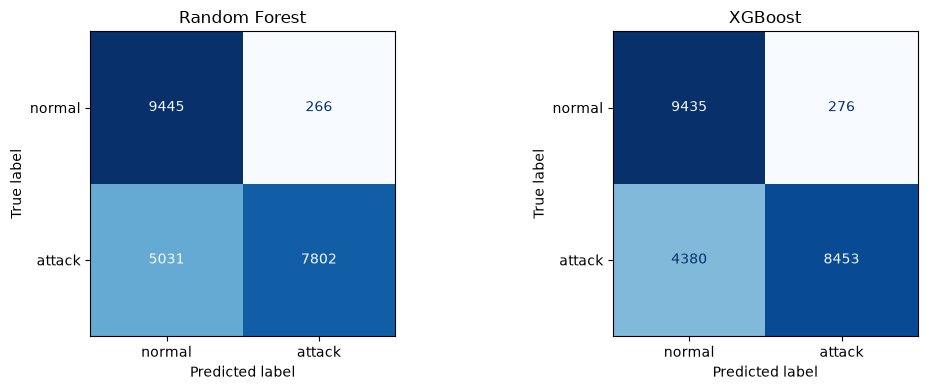

Random Forest PR-AUC: 0.96
XGBoost PR-AUC: 0.968


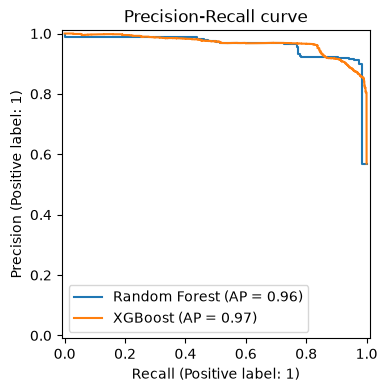

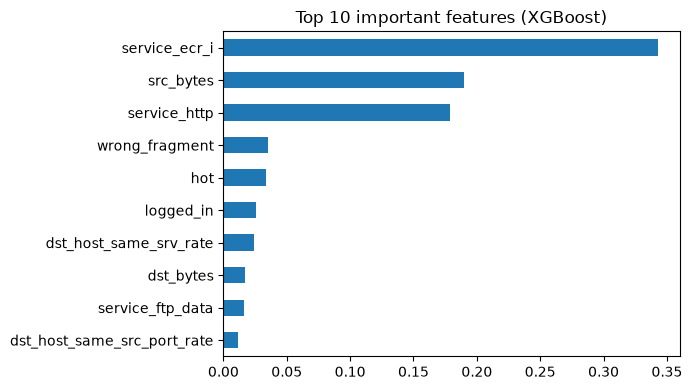

,Model,Accuracy,Attack recall,Attack precision,F1,False alarm rate,Attacks missed
0,"XGBoost, threshold 0.5",0.793,0.659,0.968,0.784,0.028,4380
1,"XGBoost, threshold 0.3",0.800,0.671,0.969,0.793,0.029,4222
2,"XGBoost, threshold 0.1",0.820,0.707,0.969,0.818,0.030,3756


In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, average_precision_score

models = {"Random Forest": rf, "XGBoost": xgb}

# 1. Confusion matrix charts: where does each model make mistakes?
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, m) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_estimator(
        m, X_test, y_test, display_labels=["normal", "attack"],
        cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

# 2. Precision-recall curve and PR-AUC
fig, ax = plt.subplots(figsize=(6, 4))
for name, m in models.items():
    PrecisionRecallDisplay.from_estimator(m, X_test, y_test, name=name, ax=ax)
    score = average_precision_score(y_test, m.predict_proba(X_test)[:, 1])
    print(name, "PR-AUC:", round(score, 3))
plt.title("Precision-Recall curve")
plt.show()

# 3. The 10 most important clues for XGBoost
imp = pd.Series(xgb.feature_importances_, index=X_train.columns)
imp.sort_values(ascending=False).head(10).sort_values().plot(
    kind="barh", figsize=(7, 4), title="Top 10 important features (XGBoost)")
plt.tight_layout()
plt.show()

# 4. Catch more attacks vs. more false alarms (XGBoost)
proba = xgb.predict_proba(X_test)[:, 1]
rows = []
for t in [0.5, 0.3, 0.1]:
    pred = (proba >= t).astype(int)
    rows.append(evaluate(f"XGBoost, threshold {t}", y_test, pred))
pd.DataFrame(rows).round(3)

In [10]:
import os
import json
import joblib

os.makedirs("models", exist_ok=True)

# Pick your best model here. XGBoost is a good default.
# If Random Forest scored better for you, change xgb to rf.
best_model = xgb

# 1. Save the model
joblib.dump(best_model, "models/attack_model.joblib")

# 2. Save the column names (the exact order the model expects)
with open("models/columns.json", "w") as f:
    json.dump(list(X_train.columns), f)

# 3. Save one real attack example, so we can test the API later
sample_row = test[test["is_attack"] == 1].iloc[0]
sample = sample_row.drop(["label", "difficulty", "is_attack"]).to_dict()
with open("models/sample_request.json", "w") as f:
    json.dump(sample, f, indent=2, default=str)

# 4. Test: load it back and make sure it gives the same answers
loaded = joblib.load("models/attack_model.joblib")
same = (loaded.predict(X_test) == best_model.predict(X_test)).all()
print("Saved model gives the same answers:", same)
print("Number of columns saved:", len(X_train.columns))
print("Files in models folder:", os.listdir("models"))


Saved model gives the same answers: True
Number of columns saved: 122
Files in models folder: ['attack_model.joblib', 'columns.json', 'sample_request.json']


In [11]:
import json
import joblib
import pandas as pd
from fastapi import FastAPI

app = FastAPI(title="Network Attack Detection API")

# Load the saved model and column order once, when the API starts
model = joblib.load("models/attack_model.joblib")
with open("models/columns.json") as f:
    columns = json.load(f)

TEXT_COLUMNS = ["protocol_type", "service", "flag"]


@app.get("/")
def home():
    return {"message": "Network attack detection API is running"}


@app.post("/predict")
def predict(connection: dict):
    # Turn the request into a one-row table
    df = pd.DataFrame([connection])

    # Make sure number columns are numbers
    for c in df.columns:
        if c not in TEXT_COLUMNS:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # Same text-to-number conversion as in training
    text_cols = [c for c in TEXT_COLUMNS if c in df.columns]
    df = pd.get_dummies(df, columns=text_cols, dtype=int)

    # Match the exact columns the model was trained on
    df = df.reindex(columns=columns, fill_value=0).fillna(0)

    prob = float(model.predict_proba(df)[0, 1])
    return {
        "prediction": "attack" if prob >= 0.5 else "normal",
        "attack_probability": round(prob, 4),
    }

In [12]:
import json
import urllib.request

data = json.load(open("models/sample_request.json"))

req = urllib.request.Request(
    "http://127.0.0.1:8000/predict",
    data=json.dumps(data).encode(),
    headers={"Content-Type": "application/json"},
)

print(urllib.request.urlopen(req).read().decode())

{"prediction":"attack","attack_probability":1.0}


In [13]:
import time
import numpy as np

times = []
for i in range(100):
    start = time.perf_counter()
    urllib.request.urlopen(req).read()
    times.append((time.perf_counter() - start) * 1000)

times = np.array(times)
print("Requests sent:", len(times))
print("Average time:", round(times.mean(), 1), "ms")
print("Median time:", round(np.median(times), 1), "ms")
print("95% of requests finished within:", round(np.percentile(times, 95), 1), "ms")

Requests sent: 100
Average time: 45.9 ms
Median time: 43.9 ms
95% of requests finished within: 53.5 ms
